# Experiment 2 — learning curves (LGD)

How R² scales with training-set size (no HPO; the four leading methods). Same structure as the PD notebook. Figures → `figures/experiment2/lgd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, imbalance_curve, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment2/lgd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment2\lgd


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment2', task='lgd', aggregated=False)
print(f'{df["method"].nunique()} methods, {df["dataset"].nunique()} datasets, '
      f'{df["sweep_value"].nunique()} sweep points')

4 methods, 4 datasets, 451 sweep points


## 1. R² vs training-set size — pooled over datasets

Four views of the same curve (one line per method, mean over datasets):
1. **raw points**, 2. **moving average** (trend), 3. **relative to each method's own best**, 4. the **moving average of that relative** curve.

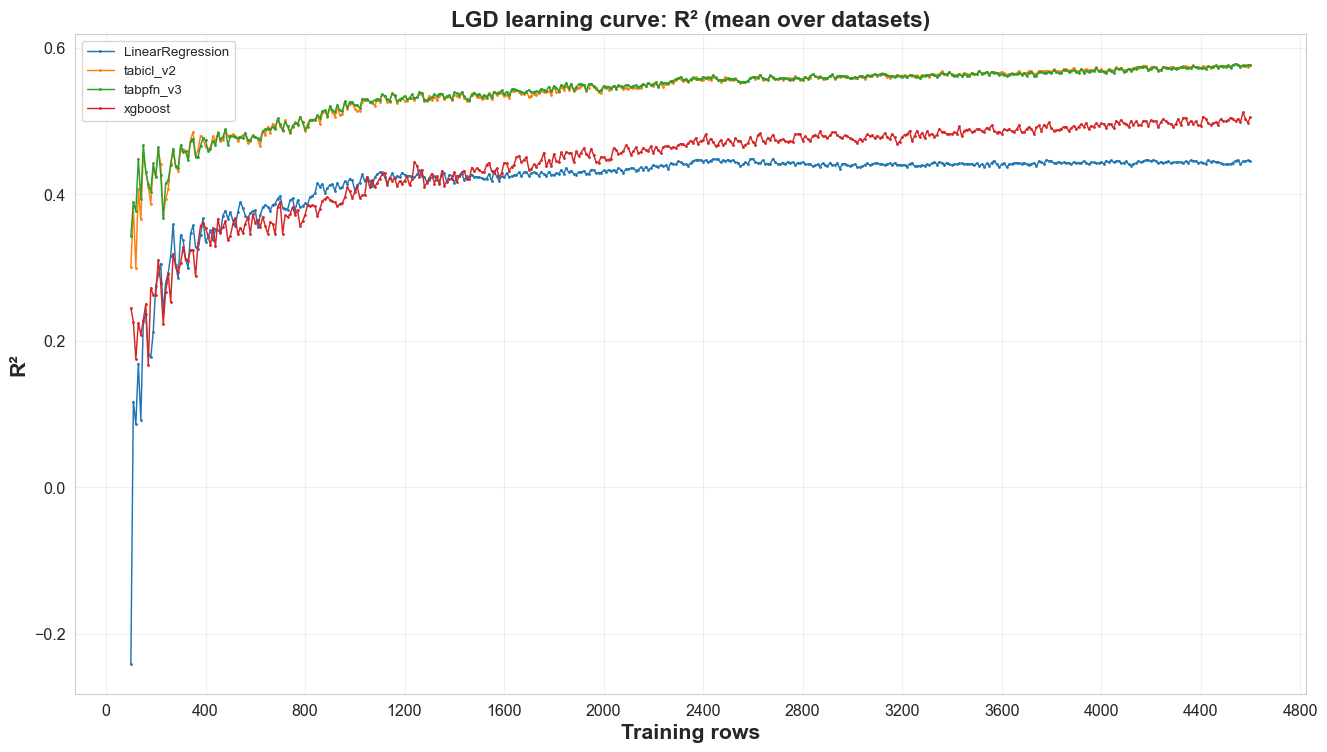

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2.pdf')

In [3]:
learning_curve(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

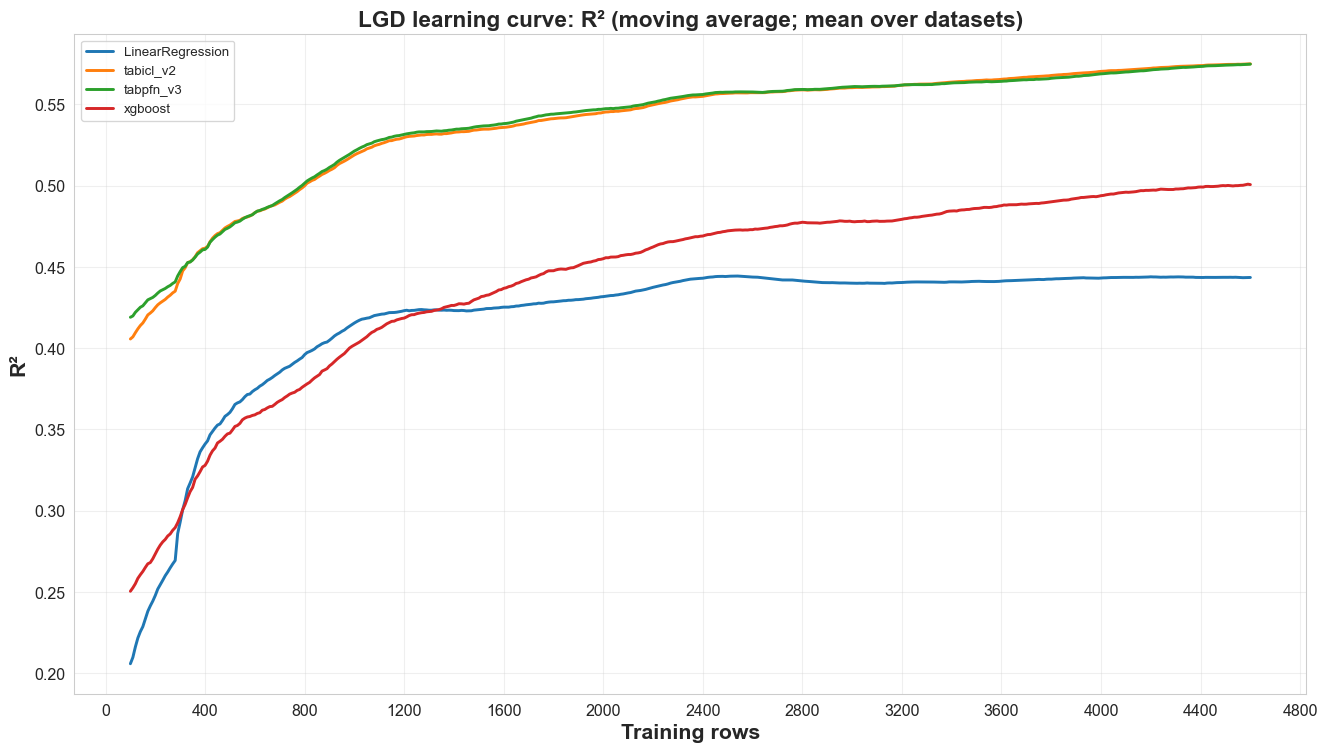

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_smooth.pdf')

In [4]:
learning_curve(df, 'R2', task_name='LGD', smooth=True, out_dir=FIGURES_DIR)

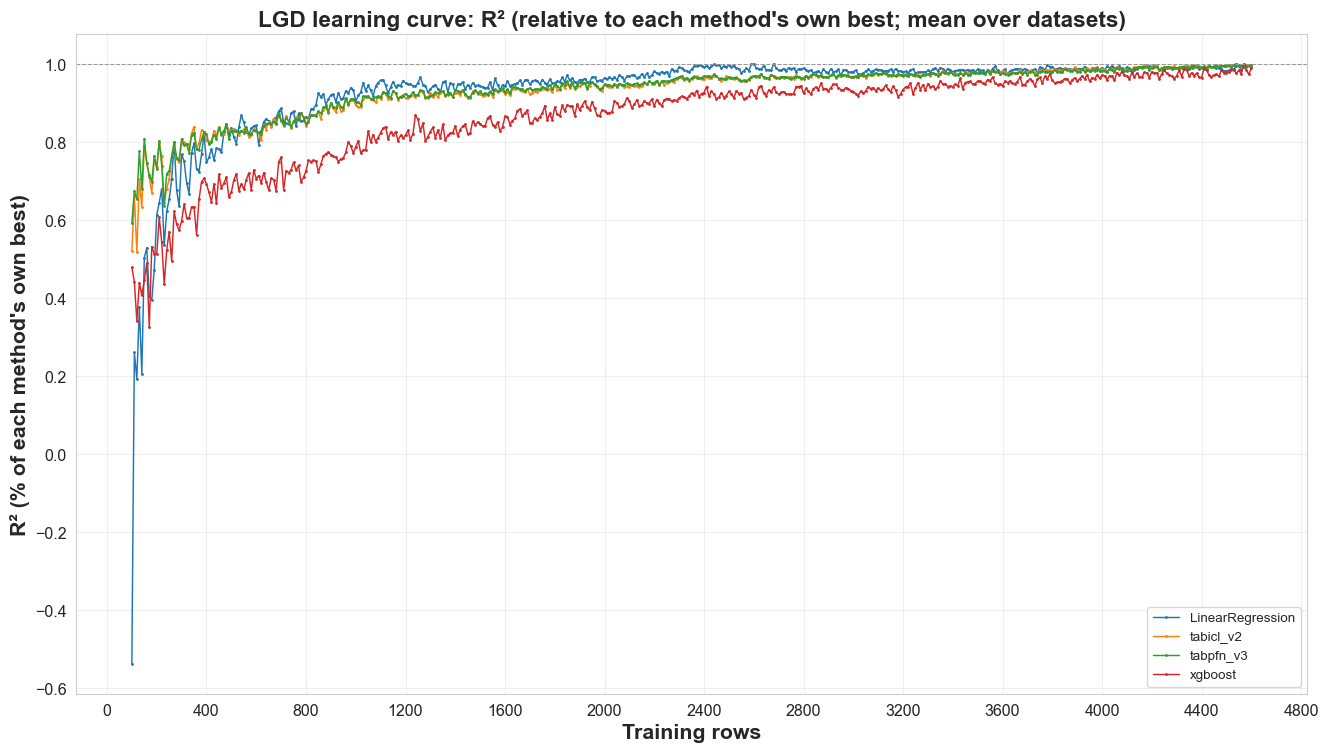

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_relative.pdf')

In [5]:
learning_curve(df, 'R2', task_name='LGD', relative=True, out_dir=FIGURES_DIR)

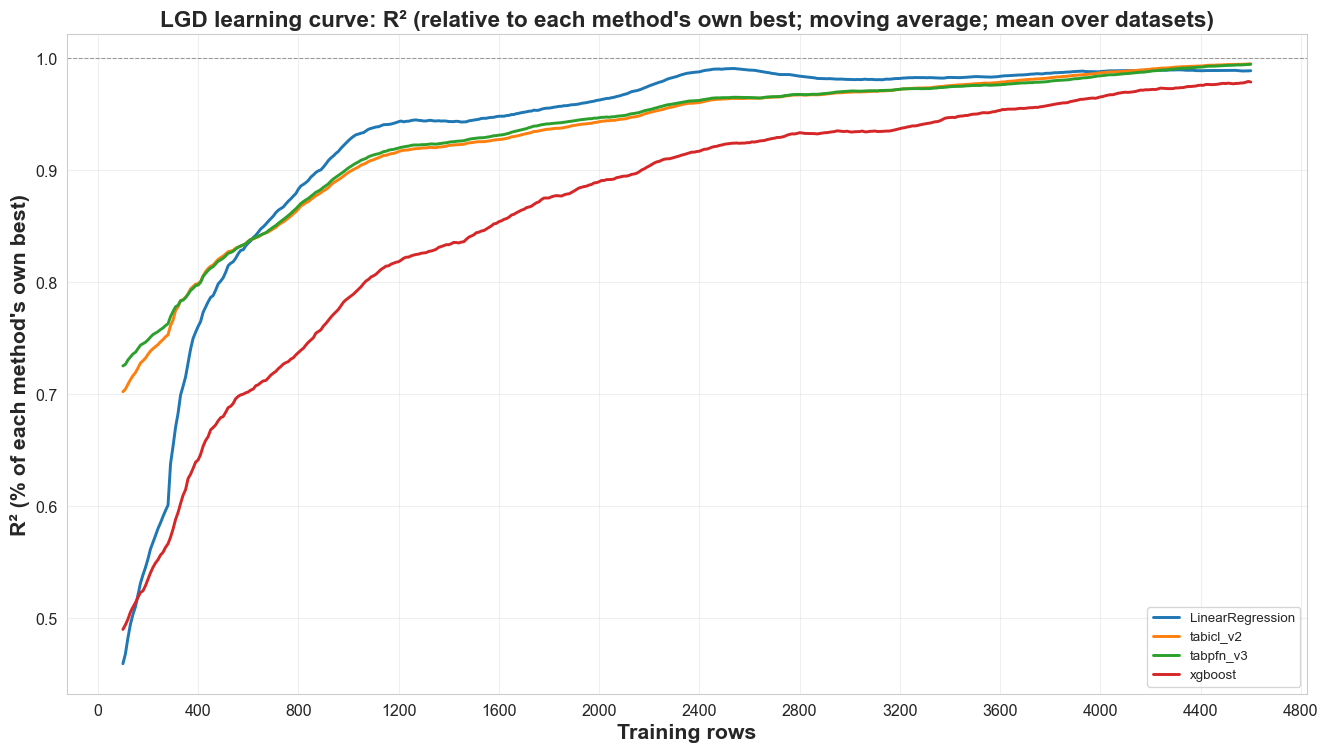

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_relative_smooth.pdf')

In [6]:
learning_curve(df, 'R2', task_name='LGD', relative=True, smooth=True, out_dir=FIGURES_DIR)

## 2. R² per dataset (raw points, all methods)

One plot per dataset so per-dataset behaviour is visible, not only the pooled mean.

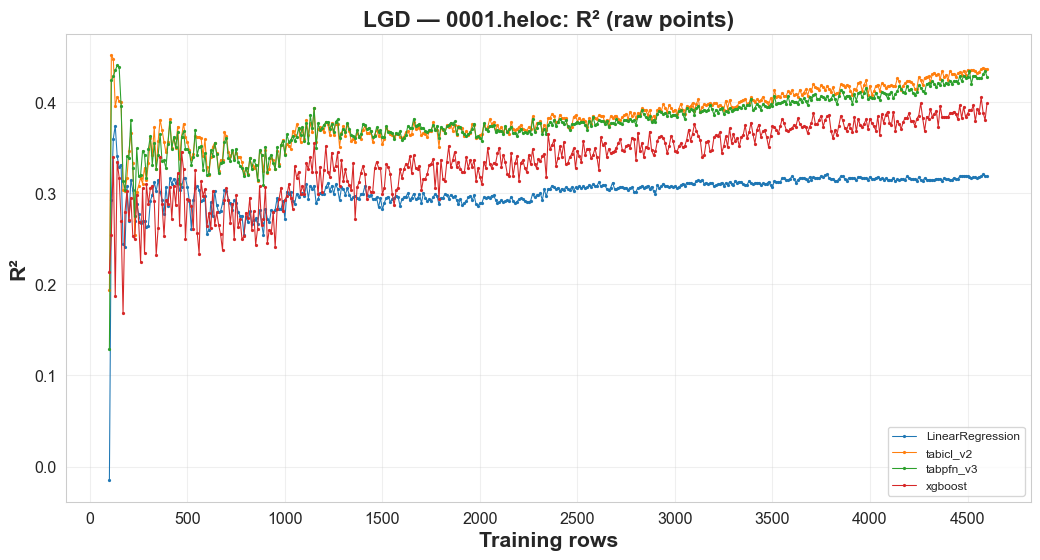

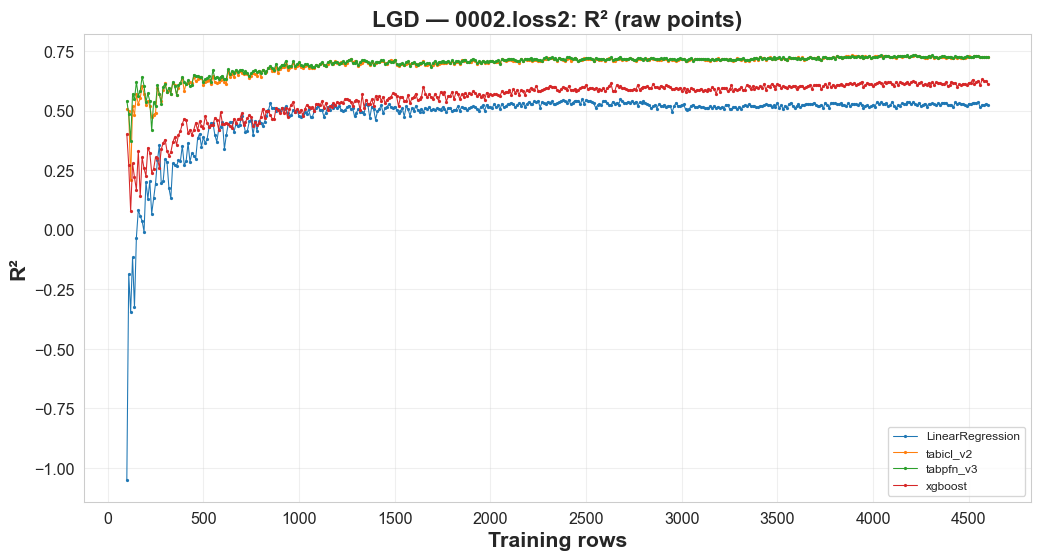

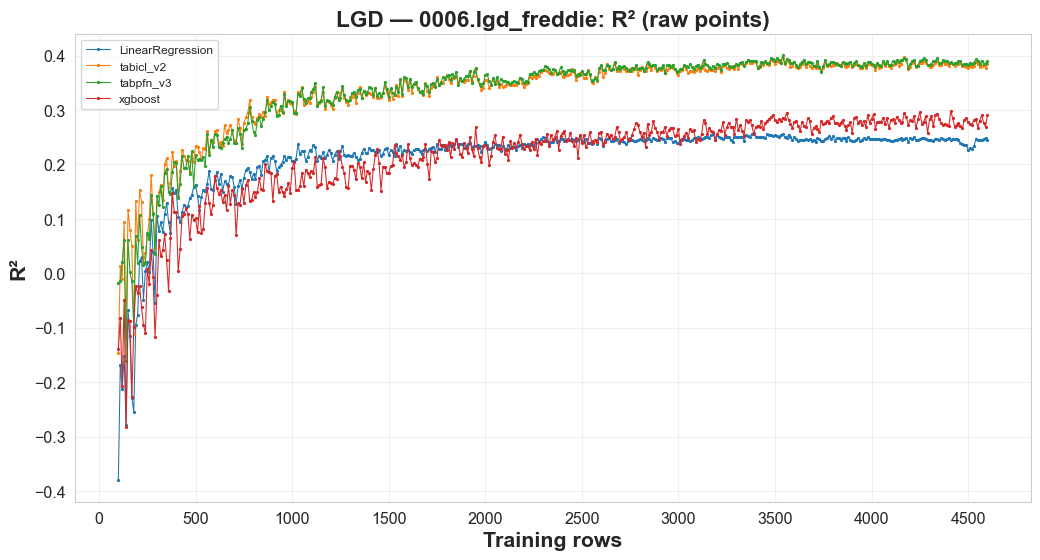

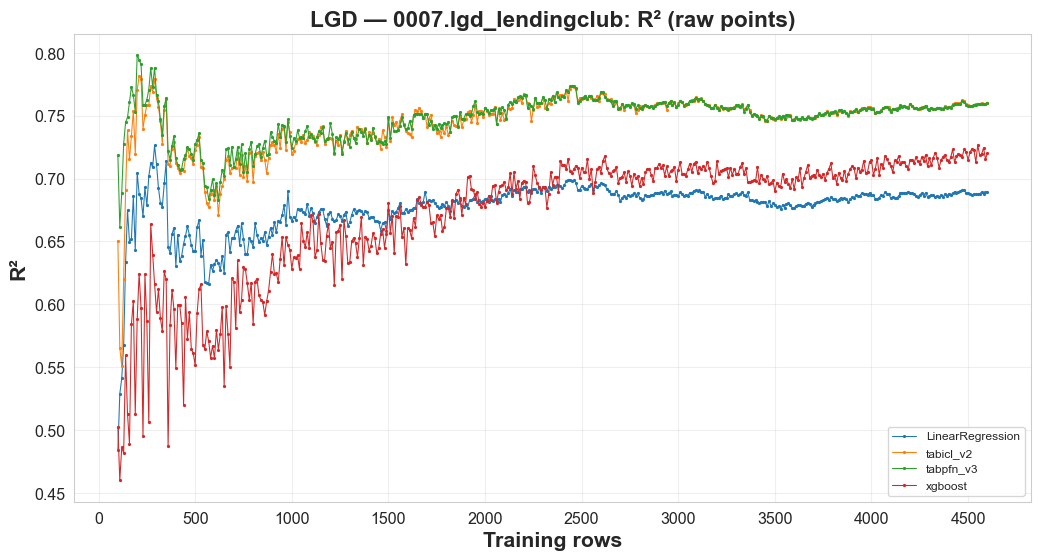

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0001_heloc_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0002_loss2_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0006_lgd_freddie_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0007_lgd_lendingclub_r2.pdf')]

In [7]:
per_dataset_sweep_curves(df, 'R2', sweep_axis='row_limit', xlabel='Training rows', task_name='LGD', out_dir=FIGURES_DIR)

## 3. Data efficiency — training rows to reach 95% of each method's own plateau

In [8]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.R2'].mean().reset_index()
rows = {}
for m, gg in g.groupby('method'):
    gg = gg.sort_values('sweep_value'); target = gg['metric.R2'].max() * 0.95
    hit = gg[gg['metric.R2'] >= target]
    rows[m] = int(hit['sweep_value'].iloc[0]) if len(hit) else None
display(_pd.Series(rows, name='rows to reach 95% of own max R2').sort_values())

LinearRegression    1030
tabpfn_v3           1830
tabicl_v2           1920
xgboost             3230
Name: rows to reach 95% of own max R2, dtype: int64

## 4. Summary — R² evolution over training-set size

Mean R² per method across all datasets at a spread of training-set sizes.

In [9]:
sweep_evolution_summary(df, 'R2', sweep_axis='row_limit',
                        task_name='Experiment 2 — LGD', log_spacing=True, n_points=18)

Experiment 2 — LGD — R² evolution over row_limit  (mean across 4 datasets; 18 of 451 sweep points; best average first)
sweep_value         100     130     160     200     250     310     390     480     610     760     950     1190    1490    1870    2340    2930    3670    4600
method                                                                                                                                                          
tabpfn_v3         0.3428  0.4484  0.4303  0.4227  0.4189  0.4571  0.4768  0.4882  0.4761  0.4964  0.5129  0.5306  0.5352  0.5508  0.5537  0.5579  0.5655  0.5761
tabicl_v2         0.3010  0.4069  0.4306  0.4252  0.4066  0.4614  0.4768  0.4879  0.4746  0.4983  0.5092  0.5311  0.5331  0.5484  0.5527  0.5568  0.5685  0.5765
xgboost           0.2447  0.2245  0.2501  0.2620  0.2915  0.3275  0.3611  0.3631  0.3649  0.3717  0.3878  0.4141  0.4349  0.4559  0.4690  0.4843  0.4941  0.5056
LinearRegression -0.2412  0.1685  0.2369  0.2747  0.2926  0.3366  0.3667  0.

"Experiment 2 — LGD — R² evolution over row_limit  (mean across 4 datasets; 18 of 451 sweep points; best average first)\n======================================================================================================================\nsweep_value         100     130     160     200     250     310     390     480     610     760     950     1190    1490    1870    2340    2930    3670    4600\nmethod                                                                                                                                                          \ntabpfn_v3         0.3428  0.4484  0.4303  0.4227  0.4189  0.4571  0.4768  0.4882  0.4761  0.4964  0.5129  0.5306  0.5352  0.5508  0.5537  0.5579  0.5655  0.5761\ntabicl_v2         0.3010  0.4069  0.4306  0.4252  0.4066  0.4614  0.4768  0.4879  0.4746  0.4983  0.5092  0.5311  0.5331  0.5484  0.5527  0.5568  0.5685  0.5765\nxgboost           0.2447  0.2245  0.2501  0.2620  0.2915  0.3275  0.3611  0.3631  0.3649  0.3717  0.3878  0.414